## Import Libraries

In [1]:
import os

os.environ["HSA_OVERRIDE_GFX_VERSION"] = "10.3.0"

In [2]:
import numpy as np

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

## Prepare train dataset

In [3]:
# Transform to turn into tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307),(0.3081,)) # mean y std
])

In [4]:
# Load the dataset and normalize it
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform
)

## Prepare test dataset

In [5]:
transform_test = transforms.ToTensor()

In [6]:
# Load the test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform_test
)

## Data Loaders

In [7]:
# DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    num_workers=4,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=128,
    num_workers=4,
    shuffle=True,
    drop_last=False
)

## Feed Forward Network 

In [8]:
import torch

print(f"¿GPU disponible?: {torch.cuda.is_available()}")
print(f"Nombre de la GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Ninguna'}")

¿GPU disponible?: True
Nombre de la GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

Entrenando en: cuda


In [19]:
import optuna

class mnistNet(nn.Module):
    def __init__(self, trial):
        super().__init__()

        out_1 = trial.suggest_int("units_l1", 32, 128)
        out_2 = trial.suggest_int("units_l2", 16, 64)
        out_3 = trial.suggest_int("unitsl3", 16, 64)

        self.input = nn.Linear(784, out_1)
        self.fc1 = nn.Linear(out_1, out_2)
        self.fc2 = nn.Linear(out_2, out_3)
        self.output = nn.Linear(out_3, 10)

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = F.relu(self.input(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return torch.log_softmax(self.output(x), dim=1)

## Training

In [20]:
def objective(trial):
    net = mnistNet(trial).to(device)
    lossfun = nn.NLLLoss()

    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSProp"])
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    optimizer = getattr(torch.optim, optimizer_name)(net.parameters(), lr=lr)

    numepochs = 15

    for epochi in range(numepochs):
        net.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            yHat = net(X)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        net.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                yHat = net(X)

                matches = torch.argmax(yHat, axis=1) == y
                correct += matches.sum().item()
                total += y.size(0)

        epoch_acc = 100 * correct / total

        trial.report(epoch_acc, epochi)

        if trial.should_prune():
            raise optuna.exception.TrialPrunned()

    return epoch_acc

In [ ]:
print("Starting Optuna Study")

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=30)

print("\n---Best Trial ---")
print(f"Accuracy: {study.best_value:2f}%")
print("Best Hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f" {key}: {value}")

[I 2026-07-11 22:16:31,722] A new study created in memory with name: no-name-593eb042-e454-44a4-9a60-39a5751bc1cb


Starting Optuna Study


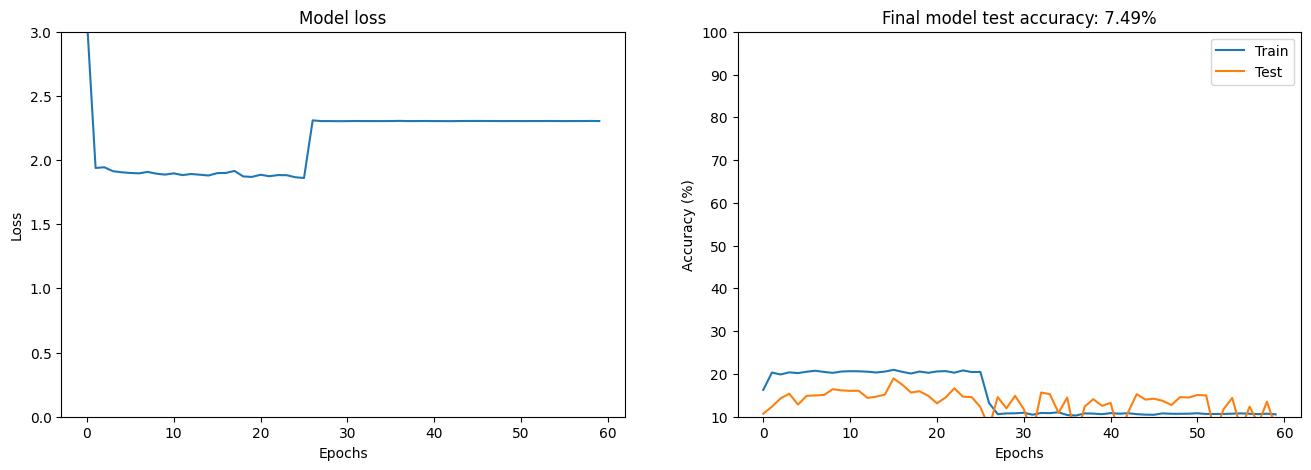

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0,3])
ax[0].set_title('Model loss')

ax[1].plot(trainAcc, label='Train')
ax[1].plot(testAcc, label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_ylim([10,100])
ax[1].set_title(f'Final model test accuracy: {testAcc[-1]:.2f}%')
ax[1].legend()


Se encontraron 959 errores en este batch.




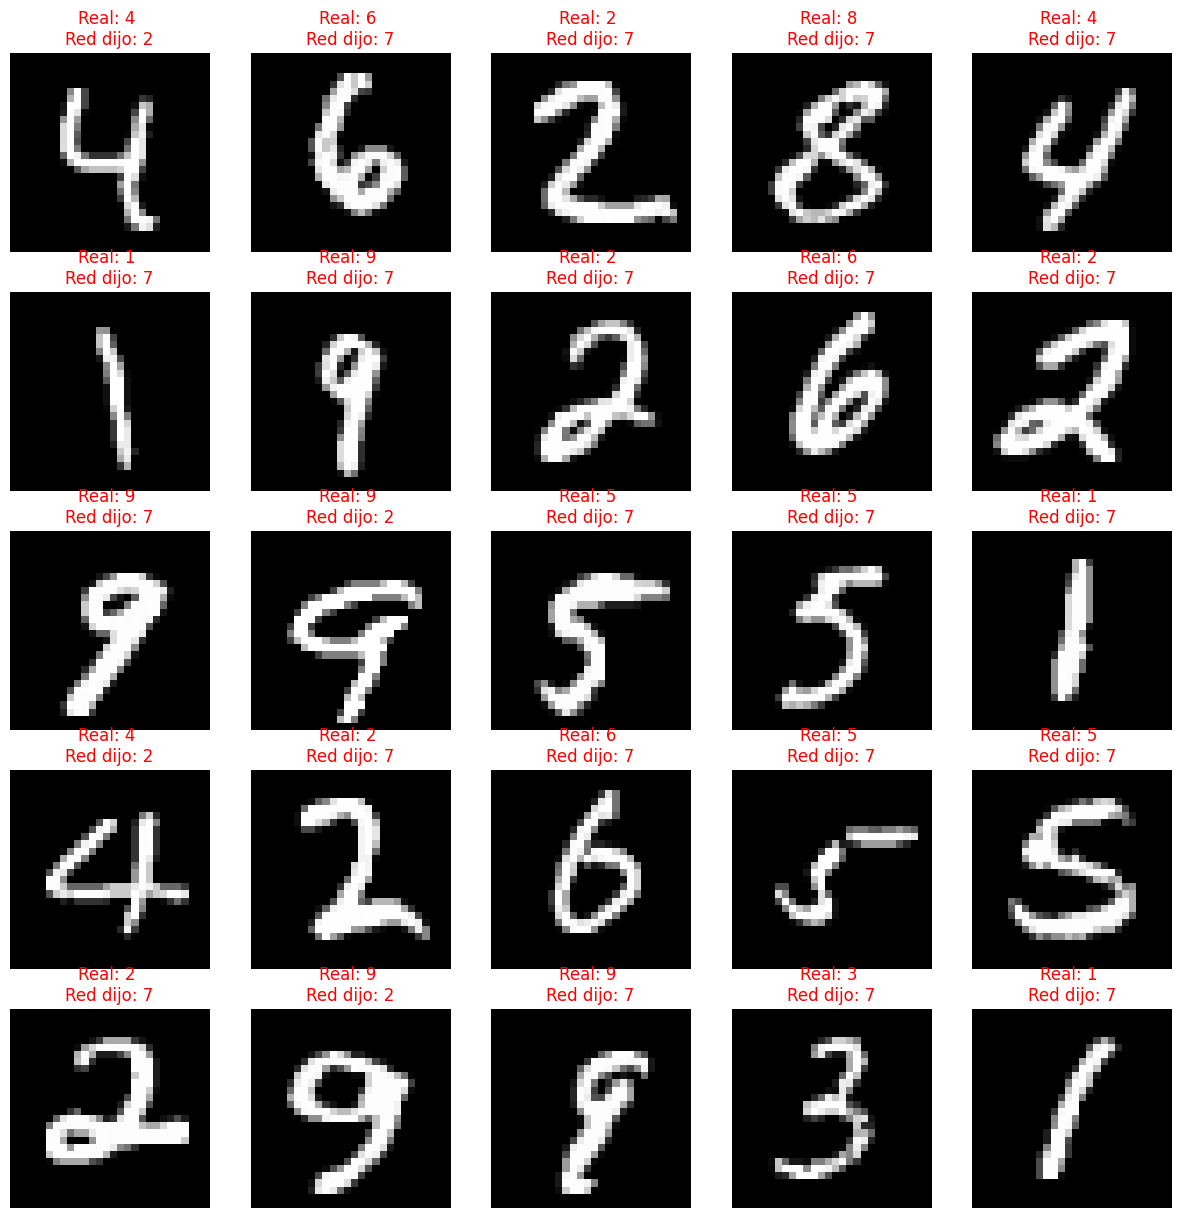

In [17]:
import math
import matplotlib.pyplot as plt
import torch

X, y = next(iter(test_loader))
X, y = X.to(device), y.to(device)

with torch.no_grad():
    predictions = net(X)

predictions = predictions.cpu()
y = y.cpu()
X = X.cpu()

predicted_classes = torch.argmax(predictions, dim=1)
errors = torch.where(predicted_classes != y)[0]

num_errors = len(errors)
print(f'\nSe encontraron {num_errors} errores en este batch.\n\n')

if num_errors > 0:
    max_to_show = min(num_errors, 25) 
    
    cols = 5 
    rows = math.ceil(max_to_show / cols)
    
    fig = plt.figure(figsize=(15, rows * 3))
    
    for i in range(max_to_show):
        error_idx = errors[i]
        true_val = y[error_idx].item()
        guess_val = predicted_classes[error_idx].item()
        
        ax = fig.add_subplot(rows, cols, i + 1)
        
        img_to_show = X[error_idx].view(28, 28)
        ax.imshow(img_to_show, cmap='gray')
        
        ax.set_title(f'Real: {true_val} \nRed dijo: {guess_val}', color='red')
        ax.axis('off') 